# Restaurant Intelligence System

## Project Overview

This project focuses on restaurant analytics, recommendation systems, predictive modeling, cuisine classification, and geospatial analysis using the Zomato Restaurant Dataset.

The system combines Data Science, Machine Learning, and Visualization techniques to generate business insights and intelligent restaurant recommendations.



# Objectives

- Perform data exploration and preprocessing
- Analyze restaurant trends and customer preferences
- Build a restaurant rating prediction model
- Create a restaurant recommendation system
- Perform cuisine classification
- Visualize restaurant distribution using maps and charts



# Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Plotly
- Seaborn
- Streamlit

In [1]:
# IMPORT REQUIRED LIBRARIES

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report
)

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Classification Models
from sklearn.linear_model import LogisticRegression

# Text Processing
from sklearn.feature_extraction.text import TfidfVectorizer

# Model Saving
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# LOAD DATASET

# Read CSV File
df = pd.read_csv("zomato.csv")
# Create Cuisine Series

cuisine_series = (
    df['Cuisines']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)
# Display First 5 Rows
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
# BASIC DATA EXPLORATION


# Display Number of Rows and Columns

print("Dataset Shape:", df.shape)

print("\nNumber of Rows:", df.shape[0])

print("Number of Columns:", df.shape[1])

Dataset Shape: (9551, 21)

Number of Rows: 9551
Number of Columns: 21


In [4]:
# DATASET INFORMATION

# Display Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [5]:
# CHECK MISSING VALUES

# Display Missing Values

missing_values = df.isnull().sum()

missing_values

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [6]:
# HANDLE MISSING VALUES

# Fill Missing Cuisines with 'Unknown'

df['Cuisines'] = df['Cuisines'].fillna('Unknown')

# Check Again

df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,0


In [7]:
# CHECK DATA TYPES

# Display Data Types

df.dtypes

,0
Restaurant ID,int64
Restaurant Name,object
Country Code,int64
City,object
Address,object
Locality,object
Locality Verbose,object
Longitude,float64
Latitude,float64
Cuisines,object


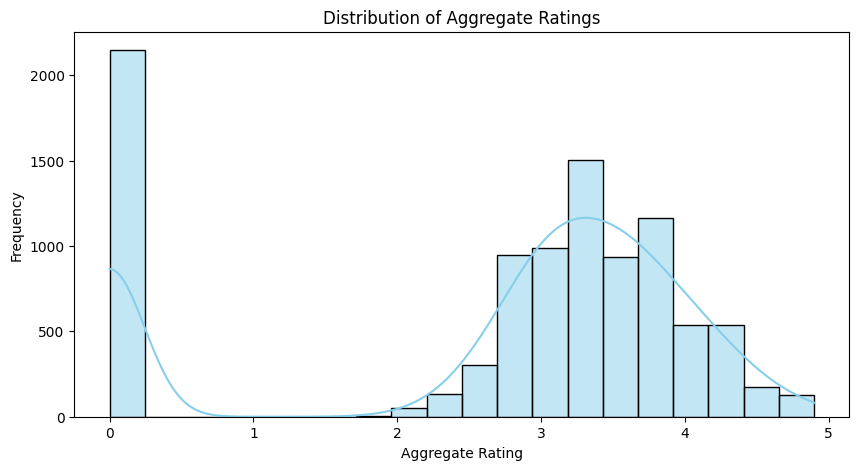

In [8]:
# TARGET VARIABLE DISTRIBUTION


plt.figure(figsize=(10,5))

sns.histplot(
    df['Aggregate rating'],
    bins=20,
    kde=True,
    color='skyblue'
)

plt.title("Distribution of Aggregate Ratings")

plt.xlabel("Aggregate Rating")

plt.ylabel("Frequency")

plt.show()

# Insight

The distribution of aggregate ratings shows that most restaurants have ratings between 3.0 and 4.5.

Very low-rated restaurants are comparatively fewer, indicating moderate class imbalance in the dataset.

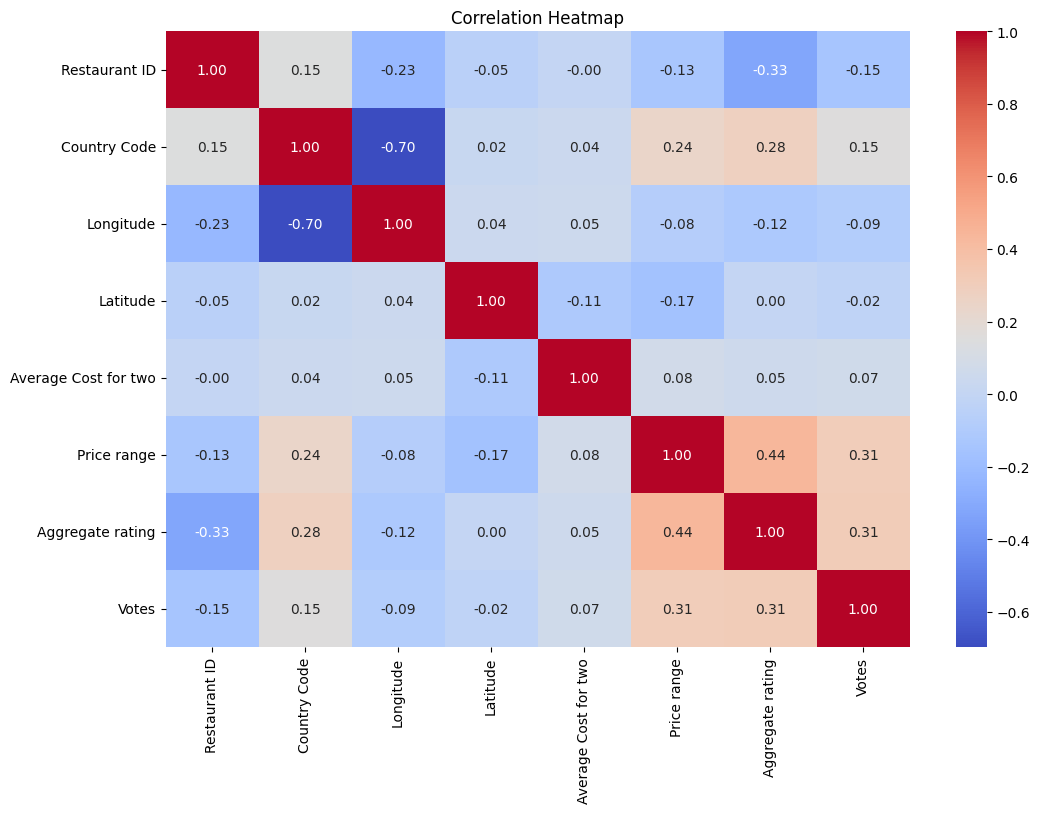

In [9]:
# CORRELATION HEATMAP

# Select Numerical Columns

numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Create Correlation Matrix

corr_matrix = numerical_df.corr()

# Plot Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

In [10]:

# DESCRIPTIVE STATISTICS

# Display Statistical Summary

df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


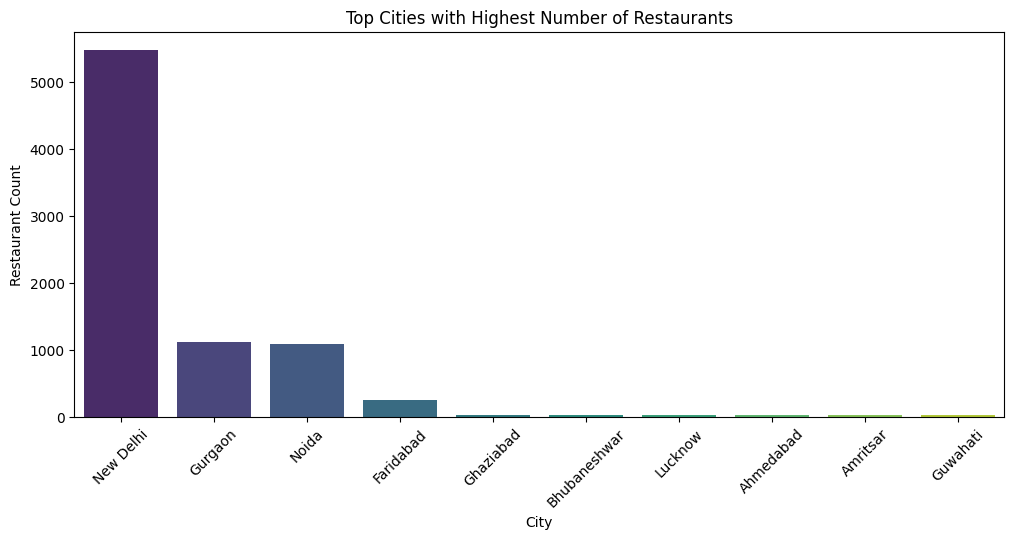

In [11]:
# TOP CITIES WITH MOST RESTAURANTS

top_cities = df['City'].value_counts().head(10)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_cities.index,
    y=top_cities.values,
    palette='viridis'
)

plt.title("Top Cities with Highest Number of Restaurants")

plt.xlabel("City")

plt.ylabel("Restaurant Count")

plt.xticks(rotation=45)

plt.show()

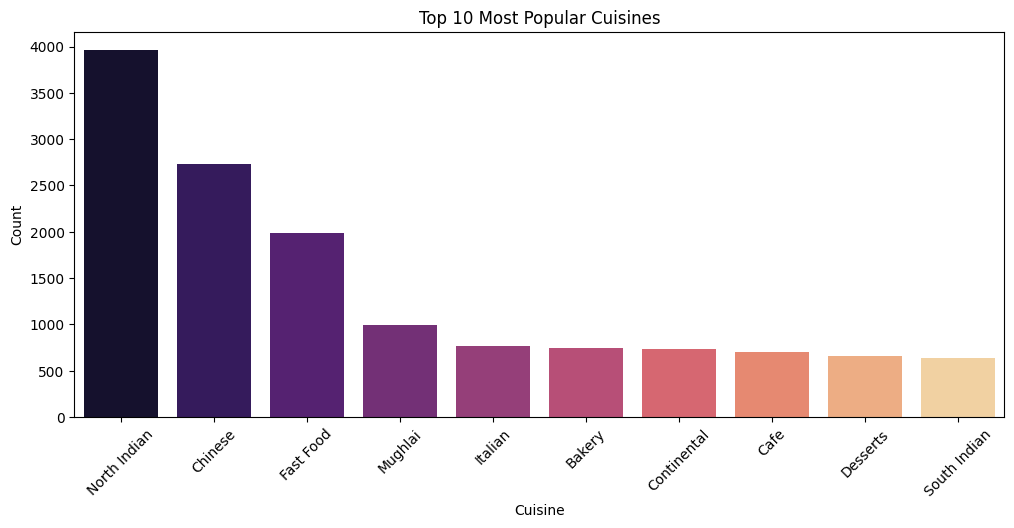

In [12]:
# TOP CUISINES


# Split Multiple Cuisines

all_cuisines = df['Cuisines'].str.split(',')

# Flatten List

cuisine_list = []

for cuisines in all_cuisines:

    for cuisine in cuisines:

        cuisine_list.append(cuisine.strip())

# Convert to Series

cuisine_series = pd.Series(cuisine_list)

# Top 10 Cuisines

top_cuisines = cuisine_series.value_counts().head(10)

# Plot

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_cuisines.index,
    y=top_cuisines.values,
    palette='magma'
)

plt.title("Top 10 Most Popular Cuisines")

plt.xlabel("Cuisine")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [13]:
# Import Folium Library

import folium

In [14]:
# Create Base Map

restaurant_map = folium.Map(
    location=[
        df['Latitude'].mean(),
        df['Longitude'].mean()
    ],
    zoom_start=5
)

restaurant_map

In [15]:
# Add Restaurant Locations to Map

sample_df = df.sample(200)

for index, row in sample_df.iterrows():

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        popup=row['Restaurant Name'],
        fill=True
    ).add_to(restaurant_map)

restaurant_map

## Insight

The map visualization shows the geographical distribution of restaurants across different cities and countries.

Restaurant concentration is higher in urban areas with greater population density and customer demand.

In [16]:
# Table Booking Percentage

table_booking_percentage = (
    df['Has Table booking']
    .value_counts(normalize=True)
    * 100
)

table_booking_percentage

,proportion
Has Table booking,
No,87.875615
Yes,12.124385


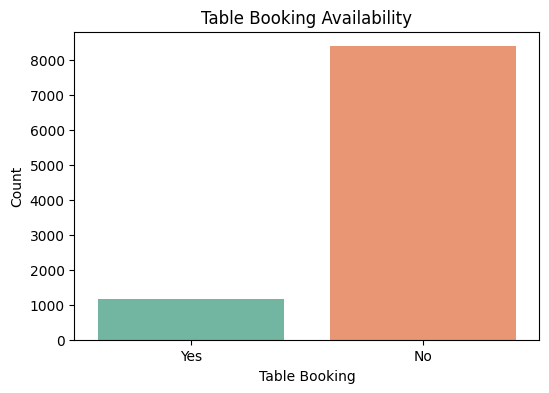

In [17]:
# Plot Table Booking Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x='Has Table booking',
    data=df,
    palette='Set2'
)

plt.title("Table Booking Availability")

plt.xlabel("Table Booking")

plt.ylabel("Count")

plt.show()

In [18]:
# Average Rating by Table Booking

booking_rating = df.groupby(
    'Has Table booking'
)['Aggregate rating'].mean()

booking_rating

,Aggregate rating
Has Table booking,
No,2.559359
Yes,3.441969


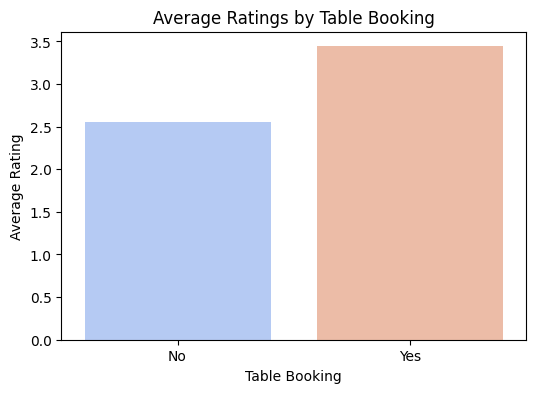

In [19]:
# Plot Average Rating Comparison

plt.figure(figsize=(6,4))

sns.barplot(
    x=booking_rating.index,
    y=booking_rating.values,
    palette='coolwarm'
)

plt.title("Average Ratings by Table Booking")

plt.xlabel("Table Booking")

plt.ylabel("Average Rating")

plt.show()

In [20]:
# Online Delivery Percentage

online_delivery_percentage = (
    df['Has Online delivery']
    .value_counts(normalize=True)
    * 100
)

online_delivery_percentage

,proportion
Has Online delivery,
No,74.337766
Yes,25.662234


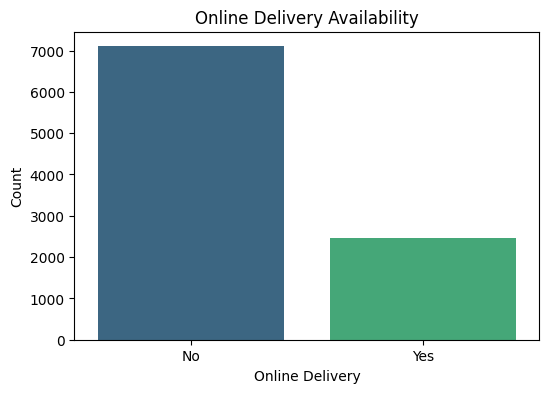

In [21]:
# Plot Online Delivery Distribution

plt.figure(figsize=(6,4))

sns.countplot(
    x='Has Online delivery',
    data=df,
    palette='viridis'
)

plt.title("Online Delivery Availability")

plt.xlabel("Online Delivery")

plt.ylabel("Count")

plt.show()

In [22]:
# Most Common Price Range

price_range_counts = df['Price range'].value_counts()

price_range_counts

,count
Price range,
1,4444
2,3113
3,1408
4,586


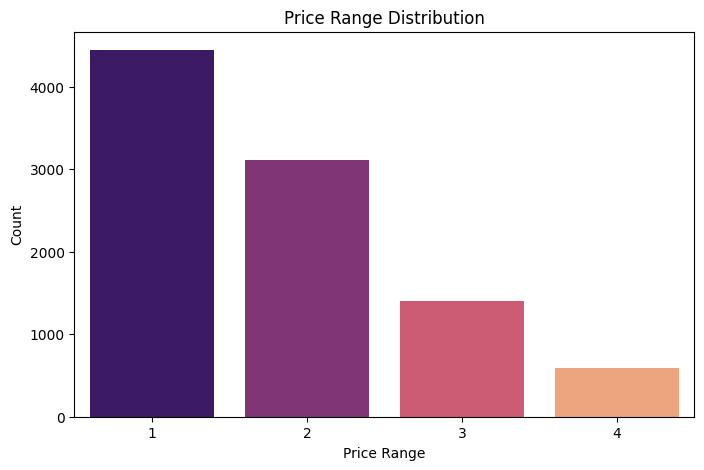

In [23]:
# Plot Price Range Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    x='Price range',
    data=df,
    palette='magma'
)

plt.title("Price Range Distribution")

plt.xlabel("Price Range")

plt.ylabel("Count")

plt.show()

In [24]:
# Average Rating by Price Range

price_rating = df.groupby(
    'Price range'
)['Aggregate rating'].mean()

price_rating

,Aggregate rating
Price range,
1,1.999887
2,2.941054
3,3.683381
4,3.817918


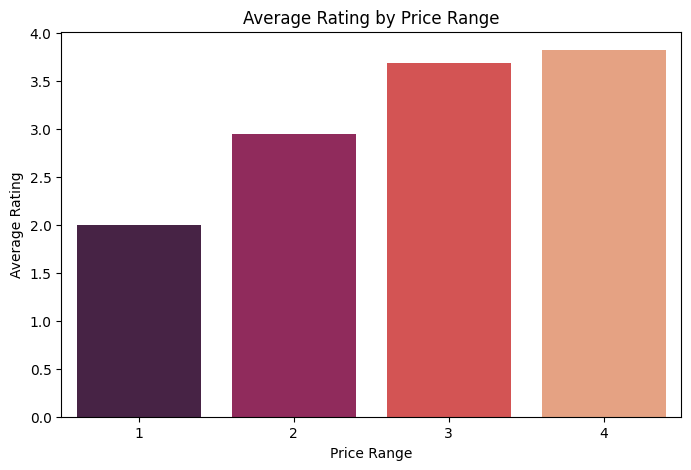

In [25]:
# Plot Average Rating by Price Range

plt.figure(figsize=(8,5))

sns.barplot(
    x=price_rating.index,
    y=price_rating.values,
    palette='rocket'
)

plt.title("Average Rating by Price Range")

plt.xlabel("Price Range")

plt.ylabel("Average Rating")

plt.show()

In [26]:
# Restaurant Name Length

df['Restaurant Name Length'] = (
    df['Restaurant Name']
    .apply(len)
)

df[['Restaurant Name', 'Restaurant Name Length']].head()

,Restaurant Name,Restaurant Name Length
0,Le Petit Souffle,16
1,Izakaya Kikufuji,16
2,Heat - Edsa Shangri-La,22
3,Ooma,4
4,Sambo Kojin,11


In [27]:
# Address Length

df['Address Length'] = (
    df['Address']
    .apply(len)
)

df[['Address', 'Address Length']].head()

,Address,Address Length
0,"Third Floor, Century City Mall, Kalayaan Avenu...",71
1,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...",67
2,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...",56
3,"Third Floor, Mega Fashion Hall, SM Megamall, O...",70
4,"Third Floor, Mega Atrium, SM Megamall, Ortigas...",64


In [28]:
# Encode Table Booking

df['Has Table Booking'] = df[
    'Has Table booking'
].map({
    'Yes': 1,
    'No': 0
})

# Encode Online Delivery

df['Has Online Delivery'] = df[
    'Has Online delivery'
].map({
    'Yes': 1,
    'No': 0
})

df[[
    'Has Table Booking',
    'Has Online Delivery'
]].head()

,Has Table Booking,Has Online Delivery
0,1,0
1,1,0
2,1,0
3,0,0
4,1,0


In [29]:
# Average Rating by Cuisine

top_cuisine_ratings = df.groupby(
    'Cuisines'
)['Aggregate rating'].mean().sort_values(
    ascending=False
).head(10)

top_cuisine_ratings

,Aggregate rating
Cuisines,
"Italian, Deli",4.9
"American, Coffee and Tea",4.9
"American, BBQ, Sandwich",4.9
"BBQ, Breakfast, Southern",4.9
"Italian, Bakery, Continental",4.9
"American, Burger, Grill",4.9
"Hawaiian, Seafood",4.9
"Mexican, American, Healthy Food",4.9
"American, Caribbean, Seafood",4.9


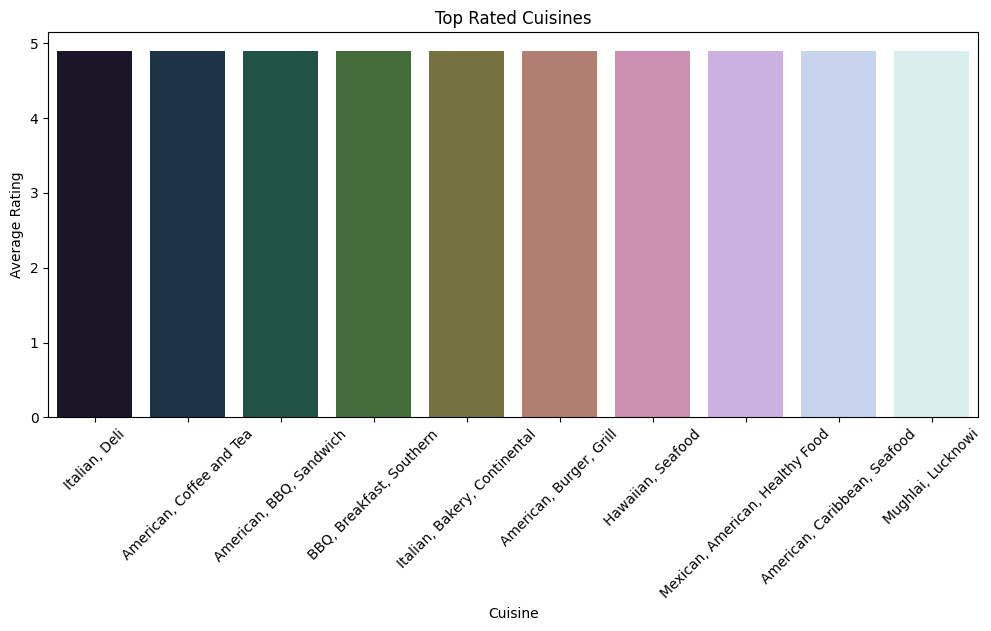

In [30]:
# Plot Top Rated Cuisines

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_cuisine_ratings.index,
    y=top_cuisine_ratings.values,
    palette='cubehelix'
)

plt.title("Top Rated Cuisines")

plt.xlabel("Cuisine")

plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

In [31]:
# Most Popular Cuisines by Votes

popular_cuisines = df.groupby(
    'Cuisines'
)['Votes'].sum().sort_values(
    ascending=False
).head(10)

popular_cuisines

,Votes
Cuisines,
"North Indian, Mughlai",53747
North Indian,46241
"North Indian, Chinese",42012
Cafe,30657
Chinese,21925
"North Indian, Mughlai, Chinese",20115
Fast Food,17852
South Indian,16433
"Mughlai, North Indian",15275


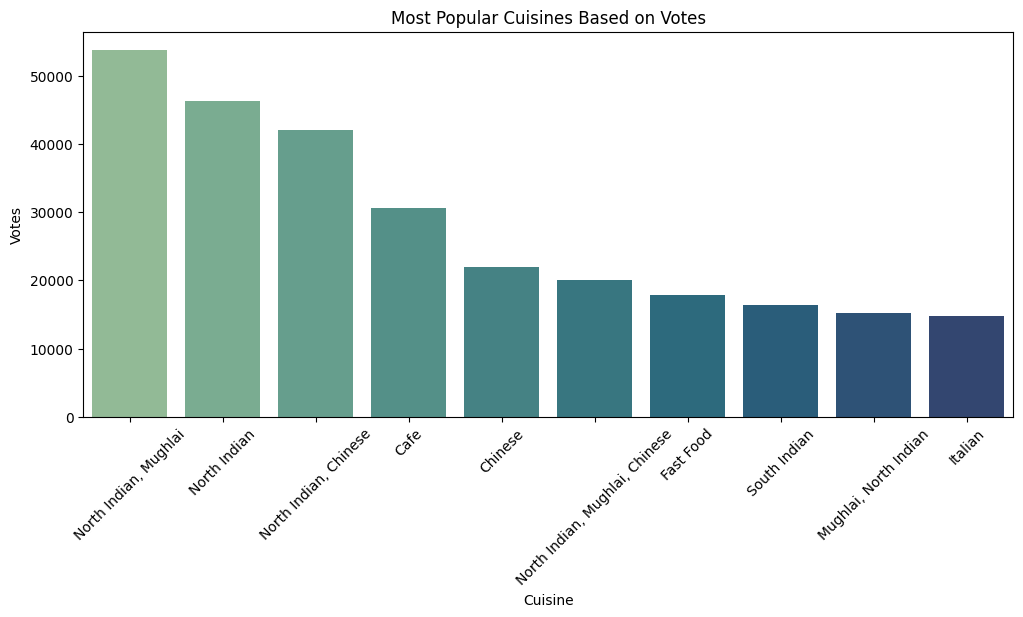

In [32]:
# Plot Most Popular Cuisines

plt.figure(figsize=(12,5))

sns.barplot(
    x=popular_cuisines.index,
    y=popular_cuisines.values,
    palette='crest'
)

plt.title("Most Popular Cuisines Based on Votes")

plt.xlabel("Cuisine")

plt.ylabel("Votes")

plt.xticks(rotation=45)

plt.show()

In [33]:
# Select Important Features

features = [
    'Votes',
    'Average Cost for two',
    'Price range',
    'Has Table Booking',
    'Has Online Delivery',
    'Restaurant Name Length',
    'Address Length'
]

target = 'Aggregate rating'

# Create Feature Matrix and Target Variable

X = df[features]

y = df[target]

X.head()

,Votes,Average Cost for two,Price range,Has Table Booking,Has Online Delivery,Restaurant Name Length,Address Length
0,314,1100,3,1,0,16,71
1,591,1200,3,1,0,16,67
2,270,4000,4,1,0,22,56
3,365,1500,4,0,0,4,70
4,229,1500,4,1,0,11,64


In [34]:
# Split Dataset into Training and Testing Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)


Training Shape: (7640, 7)
Testing Shape: (1911, 7)


In [35]:
# Scale Features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [36]:
# Train Linear Regression Model

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

# Predict Ratings

linear_predictions = linear_model.predict(
    X_test_scaled
)

# Evaluation Metrics

linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Results")

print("\nMean Squared Error:", linear_mse)

print("R2 Score:", linear_r2)

Linear Regression Results

Mean Squared Error: 1.6775321117485154
R2 Score: 0.26298252021735546


In [37]:
# Train Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

# Predict Ratings

rf_predictions = rf_model.predict(
    X_test
)

# Evaluation Metrics

rf_mse = mean_squared_error(
    y_test,
    rf_predictions
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")

print("\nMean Squared Error:", rf_mse)

print("R2 Score:", rf_r2)

Random Forest Results

Mean Squared Error: 0.11160573749462173
R2 Score: 0.9509664352762621


In [38]:
# Compare Model Performance

model_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'MSE': [
        linear_mse,
        rf_mse
    ],
    'R2 Score': [
        linear_r2,
        rf_r2
    ]
})

model_results

,Model,MSE,R2 Score
0,Linear Regression,1.677532,0.262983
1,Random Forest,0.111606,0.950966


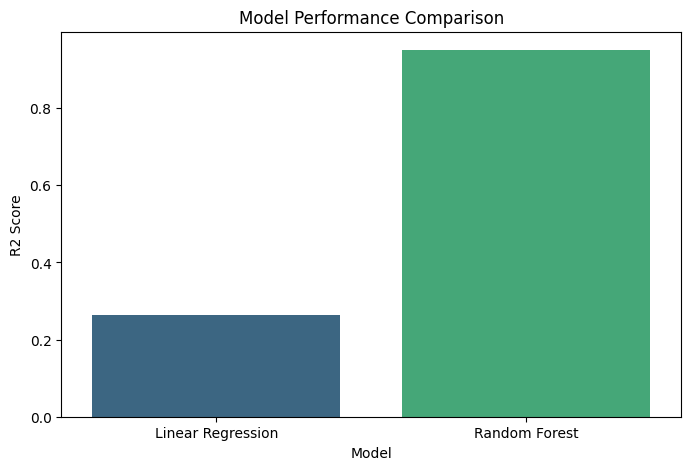

In [39]:
# Visualize Model Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=model_results,
    palette='viridis'
)

plt.title("Model Performance Comparison")

plt.ylabel("R2 Score")

plt.show()


In [40]:
# Feature Importance from Random Forest

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df

,Feature,Importance
0,Votes,0.954423
6,Address Length,0.013832
1,Average Cost for two,0.013231
5,Restaurant Name Length,0.010259
2,Price range,0.004366
4,Has Online Delivery,0.002561
3,Has Table Booking,0.001329


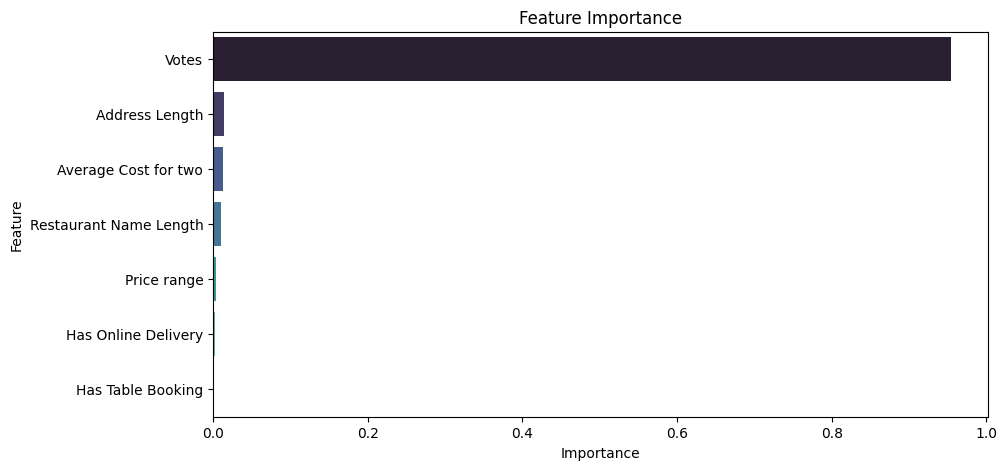

In [41]:
# Plot Feature Importance

plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df,
    palette='mako'
)

plt.title("Feature Importance")

plt.show()

In [42]:
# Save Random Forest Model

joblib.dump(
    rf_model,
    "rating_model.pkl"
)

# Save Scaler

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [43]:
# Select Cuisine Data

cuisine_df = df[[
    'Restaurant Name',
    'Cuisines'
]].copy()

cuisine_df.head()

,Restaurant Name,Cuisines
0,Le Petit Souffle,"French, Japanese, Desserts"
1,Izakaya Kikufuji,Japanese
2,Heat - Edsa Shangri-La,"Seafood, Asian, Filipino, Indian"
3,Ooma,"Japanese, Sushi"
4,Sambo Kojin,"Japanese, Korean"


In [44]:
# Keep Top 10 Most Common Cuisines

top_cuisines = cuisine_df[
    'Cuisines'
].value_counts().head(10).index

cuisine_df = cuisine_df[
    cuisine_df['Cuisines'].isin(top_cuisines)
]

cuisine_df.head()

,Restaurant Name,Cuisines
5,Din Tai Fung,Chinese
23,Caf�� Daniel Briand,Cafe
24,Casa do Biscoito Mineiro,Bakery
88,Chick-fil-A,Fast Food
93,House of China Restaurant II,Chinese


In [45]:
# Convert Restaurant Names into TF-IDF Features

vectorizer = TfidfVectorizer()

X_text = vectorizer.fit_transform(
    cuisine_df['Restaurant Name']
)

y_text = cuisine_df['Cuisines']

In [46]:
# Split Dataset

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text,
    y_text,
    test_size=0.2,
    random_state=42
)

In [47]:
# Train Logistic Regression Classifier

cuisine_model = LogisticRegression(
    max_iter=1000
)

cuisine_model.fit(
    X_train_text,
    y_train_text
)

# Predict

cuisine_predictions = cuisine_model.predict(
    X_test_text
)

# Accuracy

accuracy = accuracy_score(
    y_test_text,
    cuisine_predictions
)

print("Cuisine Classification Accuracy:")

print(accuracy)

Cuisine Classification Accuracy:
0.49361702127659574


In [48]:
# Classification Report

print(
    classification_report(
        y_test_text,
        cuisine_predictions
    )
)

                                precision    recall  f1-score   support

                        Bakery       0.59      0.46      0.52        41
              Bakery, Desserts       0.12      0.03      0.05        31
                          Cafe       0.90      0.75      0.82        57
                       Chinese       0.83      0.57      0.68        75
                     Fast Food       0.71      0.47      0.57        74
                  North Indian       0.42      0.76      0.54       191
         North Indian, Chinese       0.26      0.31      0.29       100
         North Indian, Mughlai       0.53      0.32      0.40        65
North Indian, Mughlai, Chinese       0.00      0.00      0.00        46
                   Street Food       1.00      0.36      0.53        25

                      accuracy                           0.49       705
                     macro avg       0.54      0.41      0.44       705
                  weighted avg       0.51      0.49      0.47 

In [49]:
# Save Cuisine Classification Model

joblib.dump(
    cuisine_model,
    "cuisine_model.pkl"
)

# Save TF-IDF Vectorizer

joblib.dump(
    vectorizer,
    "tfidf_vectorizer.pkl"
)

print("Cuisine model saved successfully!")

Cuisine model saved successfully!
